# Model 2_2
| Model type | Try | Comments |
|------------|-----|----------|
| 2 | 2 | GRU como capa intermedia del modelo |


In [1]:
version = "2_2"

In [2]:
import matplotlib.pyplot as plt

def show_history(history, model_name: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))  # 2 filas, 1 columna

    # Pérdida (loss)
    ax1.plot(history.history['loss'],     label='Training Loss',  color='green')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='blue')
    ax1.set_title('Loss evolution')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Precisión (accuracy)
    ax2.plot(history.history['accuracy'],     label='Training Accuracy',  color='green')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
    ax2.set_title('Accuracy evolution')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # Título global
    fig.suptitle(model_name, fontsize=16)

    # Ajustar márgenes
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [3]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [4]:
with open("../../data/normalized/df_normalized_dayOfYear.pk1", "rb") as f:
    df_data = pickle.load(f)

In [5]:
df_data.dtypes

started_at                     datetime64[ns]
ride_id                                object
year                                    int64
event                                    bool
rideable_type_classic_bike               bool
rideable_type_docked_bike                bool
rideable_type_electric_bike              bool
member_casual_bool                       bool
day_type_Holiday                         bool
day_type_Normal                          bool
day_type_Weekend                         bool
temp_std                              float64
wind_std                              float64
rel_humidity_std                      float64
precipitation_std                     float64
snow_depth_std                        float64
start_station_idx                       int64
end_station_idx                         int64
hour_sin                              float64
hour_cos                              float64
month_sin                             float64
month_cos                         

In [6]:
df_model = df_data.drop(columns=[
    "ride_id",
    "started_at",
    "member_casual_bool",
    "rideable_type_classic_bike",
    "rideable_type_docked_bike",
    "rideable_type_electric_bike",    
    "duration_min"
])

In [7]:
df_model.head()

,year,event,day_type_Holiday,day_type_Normal,day_type_Weekend,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,start_station_idx,end_station_idx,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
0,2022,False,False,True,False,-2.348318,-0.573362,0.916001,-0.099704,-0.056148,1281,1896,0.937383,0.348299,0.0,1.0,0.068802,0.997630
1,2022,False,False,True,False,-2.299739,0.115036,1.211601,-0.099704,-0.056148,1819,1645,0.144284,-0.989536,0.0,1.0,0.068802,0.997630
2,2022,False,False,True,False,-2.299739,0.225945,1.378055,-0.099704,-0.056148,1250,1250,-0.316960,-0.948439,0.0,1.0,0.068802,0.997630
3,2022,False,False,True,False,-1.705422,-0.688095,0.996358,-0.099704,-0.056148,1896,1911,-0.793088,-0.609108,0.0,1.0,0.205104,0.978740
4,2022,False,False,False,True,-2.798966,-1.130964,0.884432,-0.099704,-0.056148,1893,1646,0.798460,-0.602047,0.0,1.0,0.271958,0.962309


In [8]:
# Variables de entrada
X = df_model.drop(columns=['start_station_idx', 'end_station_idx'])
X_start = df_model['start_station_idx']
y_end   = df_model['end_station_idx']

In [9]:
def create_sequences(X, y_start, y_end, timesteps):
    X_seq, start_seq, y_seq = [], [], []

    for i in range(timesteps, len(X)):
        X_seq.append(X[i-timesteps:i])
        start_seq.append(y_start[i])
        y_seq.append(y_end[i])

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(start_seq).reshape(-1, 1),
        np.array(y_seq)
    )

# Se crea la secuencia para el GRU

In [10]:
T = 6
X_seq, X_start_seq, y_seq = create_sequences(
    X.values,
    X_start.values,
    y_end.values,
    T
)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, X_start_train, X_start_test, y_train, y_test = train_test_split(
    X_seq,
    X_start_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    shuffle=False  # MUY IMPORTANTE para series temporales
)

X_t_ctx, X_val_ctx, start_t_in, start_val_in, y_t, y_val = train_test_split(
    X_train,
    X_start_train,
    y_train,
    test_size=0.2,
    random_state=42,
    shuffle=False  # MUY IMPORTANTE para series temporales
)


In [12]:
station_offset = int(min(X_start.min(), y_end.min()))

In [13]:
num_stations = int(max(X_start.max(), y_end.max()) - station_offset + 1)
num_features = X.shape[1]

print(f"Number of stations: {num_stations}")
print(f"Number of features: {num_features}")

Number of stations: 1912
Number of features: 16


In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

embedding_dim = int(np.ceil(np.sqrt(num_stations)))

# ---------------------------
# Input 1: secuencia de contexto
# ---------------------------
context_seq_input = layers.Input(
    shape=(6, num_features),   # (T=6, F=16)
    name="context_sequence"
)

x_ctx = layers.GRU(
    128,
    return_sequences=False
)(context_seq_input)

x_ctx = layers.Dropout(0.3)(x_ctx)

# ---------------------------
# Input 2: estación origen
# ---------------------------
start_input = layers.Input(
    shape=(1,),
    name="start_station"
)

start_emb = layers.Embedding(
    input_dim=num_stations,
    output_dim=embedding_dim,
    name="start_embedding"
)(start_input)

start_emb = layers.Flatten()(start_emb)

# Procesamos el embedding (MUY buena práctica)
start_emb = layers.Dense(32, activation="relu")(start_emb)

# ---------------------------
# Concatenación
# ---------------------------
x = layers.Concatenate()([x_ctx, start_emb])

x = layers.Dense(256,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(128, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(64, activation="relu")(x)

# ---------------------------
# Output
# ---------------------------
end_output = layers.Dense(num_stations,activation="softmax",name="end_station")(x)

# ---------------------------
# Modelo final
# ---------------------------
model = Model(
    inputs=[context_seq_input, start_input],
    outputs=end_output
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True   # Añadido para resolver problemas de depuración
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_sequence    │ (None, 6, 16)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_embedding     │ (None, 1, 44)     │     84,128 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │     56,064 │ context_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 44)        │          0 │ start_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,440 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     41,216 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station (Dense) │ (None, 1912)      │    124,280 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 348,280 (1.33 MB)

 Trainable params: 348,280 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
print(X_t_ctx.shape)
print(start_t_in.shape)
print(y_t.shape)

(6086896, 6, 16)
(6086896, 1)
(6086896,)


In [16]:
print(X_val_ctx.shape)
print(start_val_in.shape)
print(y_val.shape)

(1521724, 6, 16)
(1521724, 1)
(1521724,)


In [17]:
%%time

# ---------- Callbacks
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ---------- Entrenamiento usando validation_data
history = model.fit(
    {
        "context_sequence": X_t_ctx,
        "start_station": start_t_in
    },
    y_t,
    validation_data=(
        {
            "context_sequence": X_val_ctx,
            "start_station": start_val_in
        },
        y_val
    ),
    epochs=20,
    batch_size=128,
    callbacks=[callback]
)


Epoch 1/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 4525s 95ms/step - accuracy: 0.0540 - loss: 4.9283 - val_accuracy: 0.0597 - val_loss: 4.9551
Epoch 2/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 4647s 97ms/step - accuracy: 0.0642 - loss: 4.8380 - val_accuracy: 0.0624 - val_loss: 4.9335
Epoch 3/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 4834s 102ms/step - accuracy: 0.0663 - loss: 4.8268 - val_accuracy: 0.0658 - val_loss: 4.9286
Epoch 4/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 5094s 107ms/step - accuracy: 0.0671 - loss: 4.8225 - val_accuracy: 0.0656 - val_loss: 4.9304
Epoch 5/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 5351s 112ms/step - accuracy: 0.0676 - loss: 4.8198 - val_accuracy: 0.0638 - val_loss: 4.9319
Epoch 6/20
47554/47554 ━━━━━━━━━━━━━━━━━━━━ 5557s 117ms/step - accuracy: 0.0678 - loss: 4.8189 - val_accuracy: 0.0648 - val_loss: 4.9338
CPU times: total: 8h 33min 58s
Wall time: 8h 20min 9s


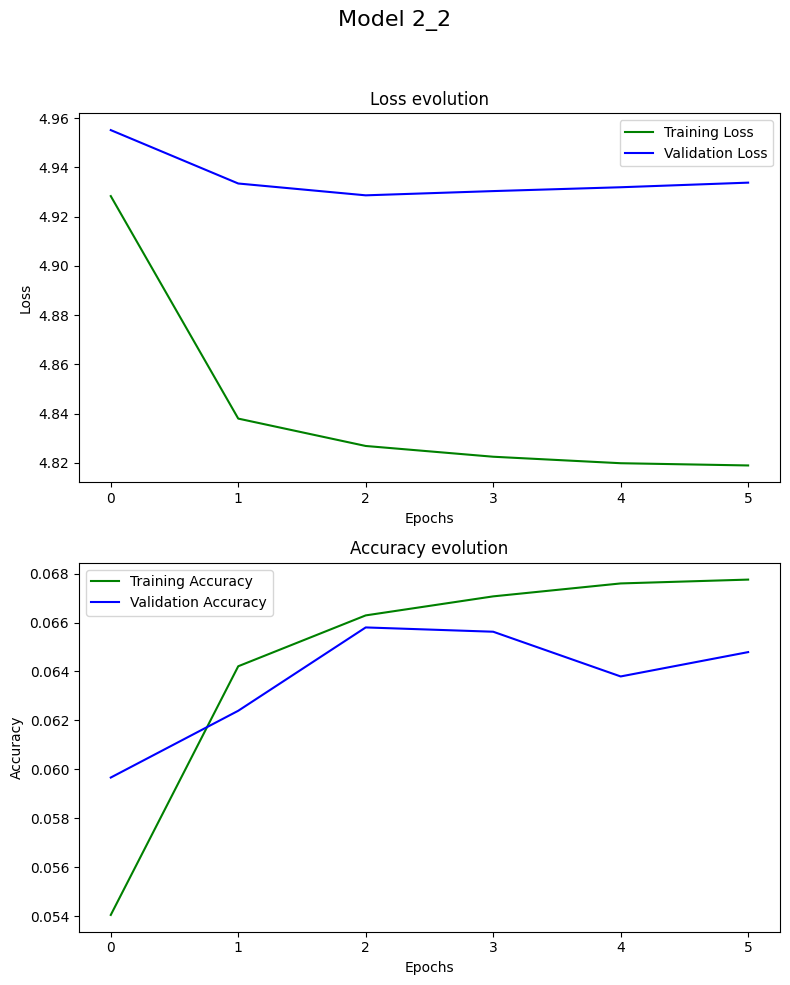

In [18]:
show_history(history, f"Model {version}")

In [19]:
model.save(f"model_{version}.keras")

with open(f'history_{version}.json', 'w') as f:
    json.dump(history.history, f)

In [20]:
with open(f'history_{version}.json', "r", encoding="utf-8") as f:
    history = json.load(f)
    
best_epoch = np.argmax(history['val_accuracy'])
best_train_acc = history['accuracy'][best_epoch]
best_val_acc = history['val_accuracy'][best_epoch]
best_val_loss = history['val_loss'][best_epoch]

print("Mejor época:", best_epoch+1)
print("Mejor train_accuracy:", best_train_acc)
print("Mejor val_accuracy:", best_val_acc)
print("Mejor val_loss:", best_val_loss)

Mejor época: 3
Mejor train_accuracy: 0.06629174947738647
Mejor val_accuracy: 0.06579971313476562
Mejor val_loss: 4.928648471832275


## Evaluación del modelo

In [21]:
# ---------- Evaluación final sobre el test set real
test_metrics = model.evaluate(
    {'context_sequence': X_test, 'start_station': X_start_test},
    y_test,
    verbose=2
)
print("Test metrics (loss, accuracy):", test_metrics)

59443/59443 - 1640s - 28ms/step - accuracy: 0.0673 - loss: 5.1088
Test metrics (loss, accuracy): [5.1088337898254395, 0.06726682931184769]
